In [1]:
from typing import Callable

import warnings
warnings.filterwarnings('ignore')

import os
import re
import pandas as pd
import numpy as np

from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.rcParams["figure.autolayout"] = True

from sklearn.linear_model import LinearRegression
mpl.style.use('dark_background')

import seaborn as sns

from src import Zero_Net, Flat_Player, Deep_Player, TRAIN_ARGS, S_GAME, M_GAME, L_GAME

In [2]:
def get_pattern(args: list[str]):
    pattern_builder = r"\[(?P<timestamp>.*?)\] "
    [*head, tail] = args
    for arg in head:
        pattern_builder += f"{arg}: (?P<{arg}>.*?), "
    pattern_builder += f"{tail}: (?P<{tail}>.*)"
    return re.compile(pattern_builder)

def create_df(results: list[dict], argdict: dict[str, Callable]) -> pd.DataFrame:
    if "timestamp" not in argdict:
        argdict["timestamp"] = lambda t: parse(t, fuzzy=True)
    df = pd.DataFrame(results)
    for key, mapfn in argdict.items():
        df[key] = df[key].map(mapfn)
    return df

def corr(df: pd.DataFrame, f1: str, f2: str) -> float:
    corr = df.corr().loc[f1, f2]
    if pd.isna(corr):
        return .0
    return corr

def autocorr(df: pd.DataFrame, f: str) -> float:
    return corr(df, "timestamp", f)

In [4]:
game_kwargs = (M, N, K) = S_GAME
game_kwargs_str = f"{M}_{N}_{K}"

assert game_kwargs_str in TRAIN_ARGS, f"Game {game_kwargs_str} not in TRAIN_ARGS"
train_params = TRAIN_ARGS[game_kwargs_str]

n_zero = train_params["n_zero"], 
n_uct = train_params["n_uct"]
n_uct_step = train_params["n_uct_step"]
n_uct_max = train_params["n_uct_max"]

IMG_DIR = f"out/{game_kwargs_str}"
TIME_DIR = os.path.join(IMG_DIR, "timeseries")
os.makedirs(TIME_DIR, exist_ok=True)
COMP_DIR = os.path.join(IMG_DIR, "competition")
os.makedirs(COMP_DIR, exist_ok=True)

In [5]:
train_keys = {
    "kl": float,
    "lr": float,
    "loss": float,
    "temp": float,
    "entropy": float,
    "expl_var": float,
    "d_expl_var": float,
}

eval_keys = {
    "n_uct": int,
    "win": int,
    "lose": int,
    "tie": int,
    "first_turn_rate": float,
}

In [6]:
train_pattern = get_pattern(train_keys)
eval_pattern = get_pattern(eval_keys)

train_results, eval_results = [], []
with open(f"bin/logs/{M}_{N}_{K}.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        train_match = train_pattern.search(line)
        if train_match is not None:
            train_results += [train_match.groupdict()]
        eval_match = eval_pattern.search(line)
        if eval_match is not None:
            eval_results += [eval_match.groupdict()]

train_df = create_df(train_results, train_keys)
eval_df = create_df(eval_results, eval_keys)

train_df_with_na = train_df.copy(deep=True)

train_df_with_na["expl_var"] = train_df_with_na["expl_var"].map(lambda x: x if x > -np.infty else np.nan)
train_df_with_na["d_expl_var"] = train_df_with_na["d_expl_var"].map(lambda x: x if x > -np.infty else np.nan)

train_df = train_df_with_na.dropna()

In [7]:
train_df.describe()

,timestamp,kl,lr,loss,temp,entropy,expl_var,d_expl_var
count,995,995.000000,995.000000,995.000000,995.000000,995.000000,995.000000,995.000000
mean,2024-02-08 12:46:54.301326592,0.009245,0.000419,1.833143,0.095575,1.218656,0.291542,0.028541
min,2024-02-08 10:34:54.786000,0.001300,0.000117,1.230530,0.000100,0.698990,0.001000,-0.002000
25%,2024-02-08 11:14:11.908499968,0.005900,0.000176,1.471675,0.000530,0.831155,0.241000,0.018000
50%,2024-02-08 12:23:01.632999936,0.008190,0.000263,1.642080,0.006440,0.961210,0.274000,0.023000
75%,2024-02-08 13:51:39.816000,0.011295,0.000263,1.851045,0.078255,1.213515,0.313000,0.033000
max,2024-02-08 16:36:42.710000,0.043580,0.006750,4.553410,0.950990,3.581480,0.687000,0.131000
std,NaN,0.004998,0.000765,0.624651,0.191251,0.662324,0.102377,0.018556


In [8]:
train_df.corr().style.background_gradient("hot")

,timestamp,kl,lr,loss,temp,entropy,expl_var,d_expl_var
timestamp,1.000000,-0.004384,-0.285670,-0.610495,-0.539264,-0.611592,-0.145201,-0.376999
kl,-0.004384,1.000000,0.019497,0.051679,0.049372,0.049363,0.035393,0.173207
lr,-0.285670,0.019497,1.000000,0.766880,0.787679,0.712575,0.019144,0.351176
loss,-0.610495,0.051679,0.766880,1.000000,0.979706,0.988781,0.422514,0.642671
temp,-0.539264,0.049372,0.787679,0.979706,1.000000,0.981945,0.480173,0.666367
entropy,-0.611592,0.049363,0.712575,0.988781,0.981945,1.000000,0.527331,0.682238
expl_var,-0.145201,0.035393,0.019144,0.422514,0.480173,0.527331,1.000000,0.607832
d_expl_var,-0.376999,0.173207,0.351176,0.642671,0.666367,0.682238,0.607832,1.000000


In [9]:
eval_df.describe()

,timestamp,n_uct,win,lose,tie,first_turn_rate
count,20,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2024-02-08 12:55:58.234000128,1350.000000,5.750000,4.200000,0.050000,0.470000
min,2024-02-08 10:42:21.880000,1000.000000,1.000000,0.000000,0.000000,0.100000
25%,2024-02-08 11:19:45.426000128,1000.000000,4.000000,2.000000,0.000000,0.400000
50%,2024-02-08 12:30:24.089999872,1000.000000,6.000000,4.000000,0.000000,0.450000
75%,2024-02-08 13:55:59.925250048,2000.000000,8.000000,6.000000,0.000000,0.600000
max,2024-02-08 16:38:25.222000,2000.000000,10.000000,9.000000,1.000000,0.900000
std,NaN,489.360485,2.314144,2.330575,0.223607,0.183819


In [10]:
eval_df.corr().style.background_gradient("hot")

,timestamp,n_uct,win,lose,tie,first_turn_rate
timestamp,1.000000,0.861297,0.087257,-0.101397,0.153791,0.339967
n_uct,0.861297,1.000000,-0.197522,0.166133,0.312641,0.181380
win,0.087257,-0.197522,1.000000,-0.995390,0.025428,0.463977
lose,-0.101397,0.166133,-0.995390,1.000000,-0.121194,-0.452106
tie,0.153791,0.312641,0.025428,-0.121194,1.000000,-0.089633
first_turn_rate,0.339967,0.181380,0.463977,-0.452106,-0.089633,1.000000


In [11]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(eval_df) * n_evaluation_games
mean_total_games = int(round(eval_df['first_turn_rate'].mean() * n_total_games))
std_total_games = int(round(eval_df['first_turn_rate'].std() * n_total_games))

round_fairness = eval_df["first_turn_rate"].mean() - .5
round_fairness_autocorr = autocorr(eval_df, "first_turn_rate")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 200 games played in total, distributed as: [94 - z * 37, 94 + z * 37]
[Warn] The number of plays which the CURRENT player started tend to increase significantly: 0.3400 > 0.05
[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.


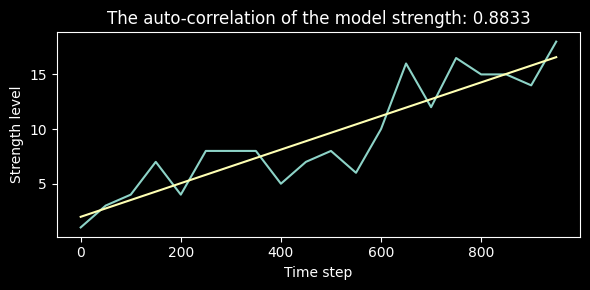

In [12]:
# Difficulty Estimation

eval_checkpoint = 50
num_wins = 10
num_playouts = n_uct_step

eval_df["batch"] = eval_df.index * eval_checkpoint
eval_df.set_index("batch", inplace=True)

eval_df["strength"] = (eval_df["win"] + eval_df["tie"] / 2 + (eval_df["n_uct"] / num_playouts  - 1) * num_wins).round(2)
eval_df["strength"] = eval_df["strength"].map(lambda x: 0 if x < 0 else x)

strength_significance = .7

strength_corr = autocorr(eval_df, "strength")
if strength_corr < strength_significance:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

x_axis = eval_df.index.values.reshape(-1, 1)

strength_lr = LinearRegression()
strength_lr.fit(x_axis, eval_df["strength"].values)

strength_estimator = lambda x: strength_lr.coef_ * x + strength_lr.intercept_

fig, axes = plt.subplots(1, 1, figsize=(6, 3))

axes = eval_df["strength"].plot(ax=axes)
axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")
axes.plot(x_axis, list(map(strength_estimator, x_axis)))
axes.set_xlabel('Time step')
axes.set_ylabel('Strength level')

# plt.show()
plt.savefig(os.path.join(IMG_DIR, "strength.png"), dpi=300)

[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training


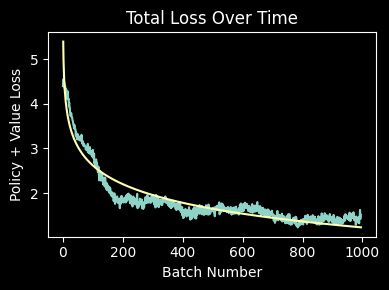

In [13]:
# Loss and Learning Rate

print(f"[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training")

loss_significance = -.5

loss_corr = autocorr(train_df, "loss")

if loss_corr > loss_significance:
    print(f"[Warn] The loss does not decrease significantly, which prevents the convergence of the model: {loss_corr:.4f} > {loss_significance}")
    print(f"[Warn] There might be a problem in loss function or hyperparameters")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1
    
loss_lr = LinearRegression()
loss_lr.fit(np.log(x_axis), train_df["loss"])
loss_estimator = lambda x: loss_lr.coef_[0] * x + loss_lr.intercept_
    
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
ax = train_df["loss"].plot(ax=axes)
ax.set_title("Total Loss Over Time")
ax.set_xlabel("Batch Number")
ax.set_ylabel("Policy + Value Loss")
ax.plot(x_axis, list(map(loss_estimator, np.log(x_axis))))

# plt.show()
plt.savefig(os.path.join(IMG_DIR, 'loss.png'), dpi=300)

[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded
[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one
[Warn] KL Divergence does not decrease over time as much as expected: -0.0044 > -0.01
[Warn] The model might still need more training or there might be other destabilizing factors causing this issue


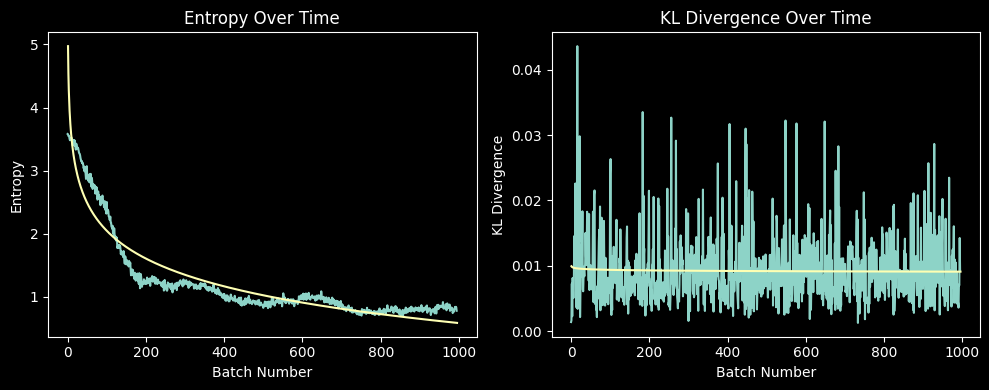

In [14]:
# Measuring Policy Estimation

print(f"[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded")
print(f"[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one")

entropy_significance = -.5
kl_significance = -0.01

entropy_corr = autocorr(train_df, "entropy")
kl_corr = autocorr(train_df, "kl")

if entropy_corr > entropy_significance:
    print(f"[Warn] Entropy seems to not decrease during training: {entropy_corr:.4f} > {entropy_significance}")
    print(f"[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive")

if kl_corr > kl_significance:
    print(f"[Warn] KL Divergence does not decrease over time as much as expected: {kl_corr:.4f} > {kl_significance}")
    print(f"[Warn] The model might still need more training or there might be other destabilizing factors causing this issue")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

entropy_lr = LinearRegression()
entropy_lr.fit(np.log(x_axis), train_df["entropy"].values)
entropy_estimator = lambda x: entropy_lr.coef_[0] * x + entropy_lr.intercept_

kl_lr = LinearRegression()
kl_lr.fit(np.log(x_axis), train_df["kl"])
kl_estimator = lambda x: kl_lr.coef_[0] * x + kl_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1 = train_df["entropy"].plot(ax=axes[0])
ax1.set_title("Entropy Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Entropy")
ax1.plot(x_axis, list(map(entropy_estimator, np.log(x_axis))))

ax2 = train_df["kl"].plot(ax=axes[1])
ax2.set_title("KL Divergence Over Time")
ax2.set_xlabel("Batch Number")
ax2.set_ylabel("KL Divergence")
ax2.plot(x_axis, list(map(kl_estimator, np.log(x_axis))))

# plt.show()
plt.savefig(os.path.join(IMG_DIR, 'entropy_kl.png'), dpi=300)

[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward
[Warn] The explained variance seems to not increase over time: -0.1452 < 0.4
[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.


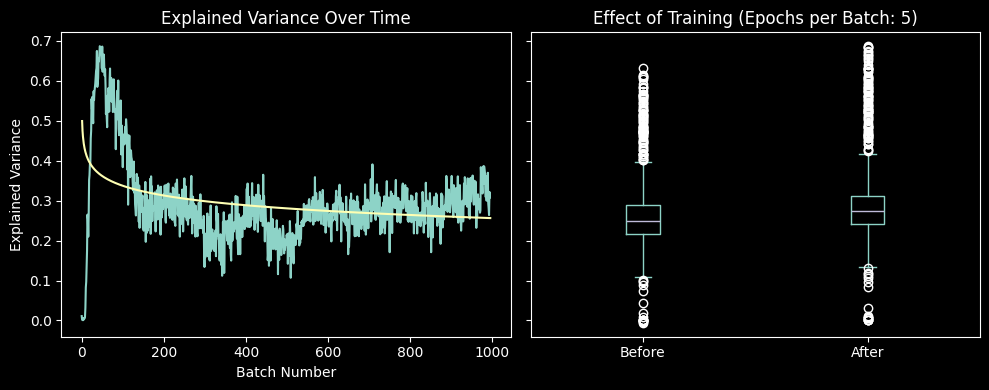

In [15]:
# Measuring Value Estimation

print(f"[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward")

expl_var_significance = .4
d_expl_varerence_significance = .01

expl_var_corr = autocorr(train_df, "expl_var")
if expl_var_corr < expl_var_significance:
    print(f"[Warn] The explained variance seems to not increase over time: {expl_var_corr:.4f} < {expl_var_significance}")
    print(f"[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.")

d_expl_varerence = train_df["d_expl_var"].mean()
if d_expl_varerence < d_expl_varerence_significance:
    print(f"[Warn] The new explained variance tends not to differ significantly from the older one: {d_expl_varerence:.4f} < {d_expl_varerence_significance}")
    print(f"[Warn] Either the value loss is set correctly or the learning rate is too small")

n_epochs = 5

x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

expl_var_lr = LinearRegression()
expl_var_lr.fit(np.log(x_axis), train_df["expl_var"].values)
expl_var_estimator = lambda x: expl_var_lr.coef_ * x + expl_var_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1 = train_df["expl_var"].plot(ax=axes[0])
ax1.set_title("Explained Variance Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Explained Variance")
ax1.plot(x_axis, list(map(expl_var_estimator, np.log(x_axis))))

d_expl_varerence_stats = pd.concat([train_df['expl_var'] - train_df['d_expl_var'], train_df['expl_var']], axis=1)
ax2 = d_expl_varerence_stats.plot(kind="box", ax=axes[1])
ax2.set_title(f"Effect of Training (Epochs per Batch: {n_epochs})")
ax2.set_xticklabels(["Before", "After"])

# plt.show()
plt.savefig(os.path.join(IMG_DIR, 'expl_var.png'), dpi=300)

In [16]:
def plot_competition(
    n_games: int,
    results_lengths: pd.DataFrame,
    results_counts: pd.DataFrame, 
    axes: tuple[tuple[plt.Axes, plt.Axes], tuple[plt.Axes, plt.Axes]],
):    
    sns.violinplot(data=results_lengths, ax=axes[1])
    axes[1].set_title(f"Game Length (n = {n_games})")
    axes[1].set_ylabel("Length")
    axes[1].set_xlabel("Outcome")
    axes[1].set_xticklabels([])
    axes[1].legend(
        prop={'size': 8},
        loc="upper left", 
        fancybox=True,
        shadow=True,
        labels=results_lengths.columns,
    )
        
    sns.heatmap(results_counts, cmap="summer", annot=True, ax=axes[0])
    axes[0].set_title(f"Outcome Ratio (n = {n_games})")

In [18]:
n_games = 10
    
lengths = []
counts = []
for comp in os.listdir(COMP_DIR):
    if comp.endswith("lengths.csv"):
        lengths += [os.path.join(COMP_DIR, comp)]
    elif comp.endswith("counts.csv"):
        counts += [os.path.join(COMP_DIR, comp)]

lengths, counts = sorted(lengths), sorted(counts)
for length_path, count_path in zip(lengths, counts):
    plot_path = length_path.replace("_lengths.csv", ".png")
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    results_lengths = pd.read_csv(length_path, index_col=0)
    results_counts = pd.read_csv(count_path, index_col=0)
    
    plot_competition(n_games, results_lengths, results_counts, axes)
    
    plt.savefig(plot_path, dpi=300)
    plt.close(fig)

In [20]:
for tseries in os.listdir(TIME_DIR):
    if tseries.endswith(".csv"):
        name = tseries.replace(".csv", "")
        time_path = os.path.join(TIME_DIR, tseries)
        df = pd.read_csv(time_path, index_col=0)
        df.dropna(axis=1, how='all', inplace=True)

        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        sns.violinplot(data=df, ax=ax)
        ax.set_xlabel("Turn")
        ax.set_ylabel("Time (s)")
        ax.set_title(f"Time Series of {name}")
        
        plt.savefig(os.path.join(TIME_DIR, f"{name}.png"), dpi=300)
        plt.close(fig)

## Game Is Solved For 6, 6, 4!

In [33]:
# # Fairness of Game

# from src import Gomoku, Pattern

# Pi_s = "c3,d4,b4,d2,d3,e3,b3,a3,b2,c5,b1" # winning strategy for the first player

# V_s = []
# Q_sa = []

# game = Gomoku(*SMALL_GAME)
# for move in Pattern.loc_to_move(Pi_s):
#     probs, value = net.predict(game)
#     max_prob, max_action = max(probs)
#     assert max_action == move, "The best policy is different from the given move"
#     game.play(move)
#     V_s += [value.detach().item()]
#     Q_sa += [max_prob]
    
# x_axis = Pi_s.split(",")
# ax = plt.subplot(1, 1, 1)
# ax.plot(x_axis, V_s)
# ax.plot(x_axis, Q_sa)
# ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")
# ax.set_ylim(-1, 1)
# ax.set_xlabel("Move")
# ax.set_ylabel("Value")
# ax.set_title("Analysis of Best Policy")
# ax.legend(["V(s)", "Q(s, a)", "Fairness"])
# # plt.show()
# plt.savefig("imgs/fairness_6_6_4.png", dpi=300)